获取数据

数据来源: 本地缓存
缓存文件: D:\proj\xquant\xquant-learning-sxl\q1\data\510300_SS_2021-01-01_2026-08-14_auto_adjust.csv
               Close      High       Low      Open     Volume
Date                                                         
2021-01-04  4.762662  4.791235  4.696589  4.714447  506705639
2021-01-05  4.851058  4.861773  4.736769  4.751055  622830794
2021-01-06  4.894810  4.923382  4.836772  4.863559  374945107
2021-01-07  4.999278  5.000170  4.895702  4.901953  470659227
2021-01-08  4.974277  5.027850  4.927847  5.007314  697564767

数据范围: 2021-01-04 到 2026-08-14
数据总行数：1360


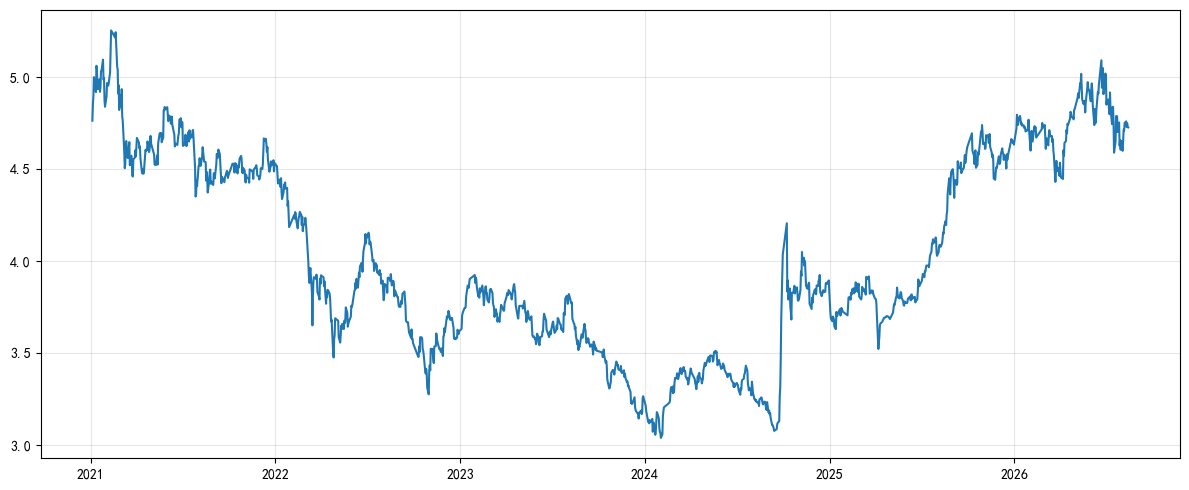

In [1]:
from pathlib import Path

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取数据：相同标的和日期范围优先读取本地缓存
TICKER = '510300.SS'
DATA_START = '2021-01-01'
DATA_END = '2026-08-14'

# 兼容从项目根目录或 q1 目录启动 Jupyter 的两种情况
cwd = Path.cwd()
notebook_dir = cwd if (cwd / 'strategy.ipynb').exists() else cwd / 'q1'
cache_dir = notebook_dir / 'data'
cache_file = cache_dir / f"{TICKER.replace('.', '_')}_{DATA_START}_{DATA_END}_auto_adjust.csv"

download_end = (pd.Timestamp(DATA_END) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

if cache_file.exists():
    df = pd.read_csv(cache_file, index_col='Date', parse_dates=['Date'])
    data_source = '本地缓存'
else:
    df = yf.download(
        TICKER,
        start=DATA_START,
        end=download_end,
        auto_adjust=True,
        multi_level_index=False,
        progress=False,
        threads=False,
    )
    df = df.loc[:DATA_END]
    if df.empty:
        raise RuntimeError(
            'Yahoo Finance 未返回数据，且本地缓存不存在。请停止重复请求，'
            '稍后重试或更换网络出口；本次不会写入空缓存。'
        )
    cache_dir.mkdir(parents=True, exist_ok=True)
    df.index.name = 'Date'
    df.to_csv(cache_file)
    data_source = 'Yahoo Finance（已写入本地缓存）'

df.index = pd.to_datetime(df.index)
df = df.sort_index().loc[DATA_START:DATA_END]
if df.empty or 'Close' not in df.columns:
    raise ValueError(f'数据或缓存格式无效: {cache_file}')

print(f'数据来源: {data_source}')
print(f'缓存文件: {cache_file.resolve()}')
print(df.head())
print(f"\n数据范围: {df.index[0].date()} 到 {df.index[-1].date()}")
print(f'数据总行数：{len(df)}')

# 画图
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], linewidth=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

定投回测

投资期间: 2021-01 到 2026-08
投资月数: 68
总投入: 68,000 元
最终市值: 80,971 元
最终收益率: 19.08%


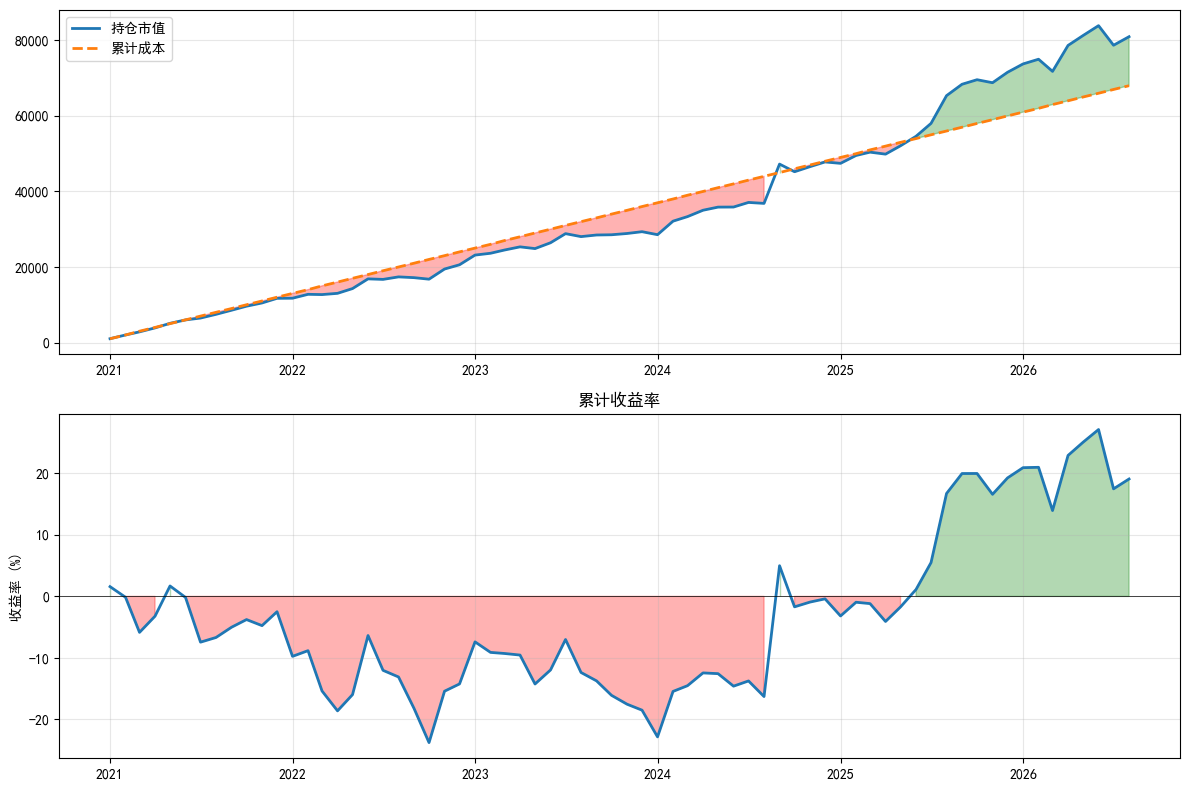

In [2]:
def backtest_dca(df, mouthly_amount=1000):
    """
    定投回测
    """
    df = df.copy()
    df['month'] = df.index.to_period('M')

    # 每月第一个交易日买入
    mouthly_first = df.groupby('month').first()
    shares_bought = mouthly_amount / mouthly_first['Close']
    total_shares = shares_bought.cumsum()
    total_cost = mouthly_amount * np.arange(1, len(mouthly_first) + 1)

    # 每月末市值
    mouthly_last = df.groupby('month').last()
    portfolio_value = total_shares * mouthly_last['Close']
    returns = (portfolio_value.values - total_cost) / total_cost

    result_dca = pd.DataFrame({
        'total_cost': total_cost, # 总花费
        'total_shares': total_shares, # 持有股数
        'portfolio_value': portfolio_value, # 当前市值
        'return': returns # 收益率
    }, index=mouthly_first.index)
    return result_dca

result_dca = backtest_dca(df)

print(f"投资期间: {result_dca.index[0]} 到 {result_dca.index[-1]}")
print(f"投资月数: {len(result_dca)}")
print(f"总投入: {result_dca['total_cost'].iloc[-1]:,.0f} 元")
print(f"最终市值: {result_dca['portfolio_value'].iloc[-1]:,.0f} 元")
print(f"最终收益率: {result_dca['return'].iloc[-1]:.2%}")

# 可视化
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
ts = result_dca.index.to_timestamp()

ax1 = axes[0]
ax1.plot(ts, result_dca['portfolio_value'], label='持仓市值', linewidth=2)
ax1.plot(ts, result_dca['total_cost'], label='累计成本', linewidth=2, linestyle='--')
ax1.fill_between(ts, result_dca['total_cost'], result_dca['portfolio_value'],
                  where=result_dca['portfolio_value'] > result_dca['total_cost'],
                  alpha=0.3, color='green')
ax1.fill_between(ts, result_dca['total_cost'], result_dca['portfolio_value'],
                  where=result_dca['portfolio_value'] <= result_dca['total_cost'],
                  alpha=0.3, color='red')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(ts, result_dca['return'] * 100, linewidth=2)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.fill_between(ts, 0, result_dca['return'] * 100,
                  where=result_dca['return'] > 0, alpha=0.3, color='green')
ax2.fill_between(ts, 0, result_dca['return'] * 100,
                  where=result_dca['return'] <= 0, alpha=0.3, color='red')
ax2.set_ylabel('收益率 (%)')
ax2.set_title('累计收益率')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


基准：一次性买入持有

沪深300ETF 起点价格: 4.763
沪深300ETF 终点价格: 4.726

一次性买入收益率: -0.77%
定投收益率: 19.08%
差异: 19.85%
沪深300ETF 起点价格: 4.763
沪深300ETF 终点价格: 4.726

一次性买入收益率: -0.77%
定投收益率: 19.08%
差异: 19.85%

→ 定投跑赢了一次性买入！
  在下跌市中，定投通过分批买入避开了部分高位。

但两种策略都没有 Alpha——收益完全取决于市场涨跌，这就是 Beta。


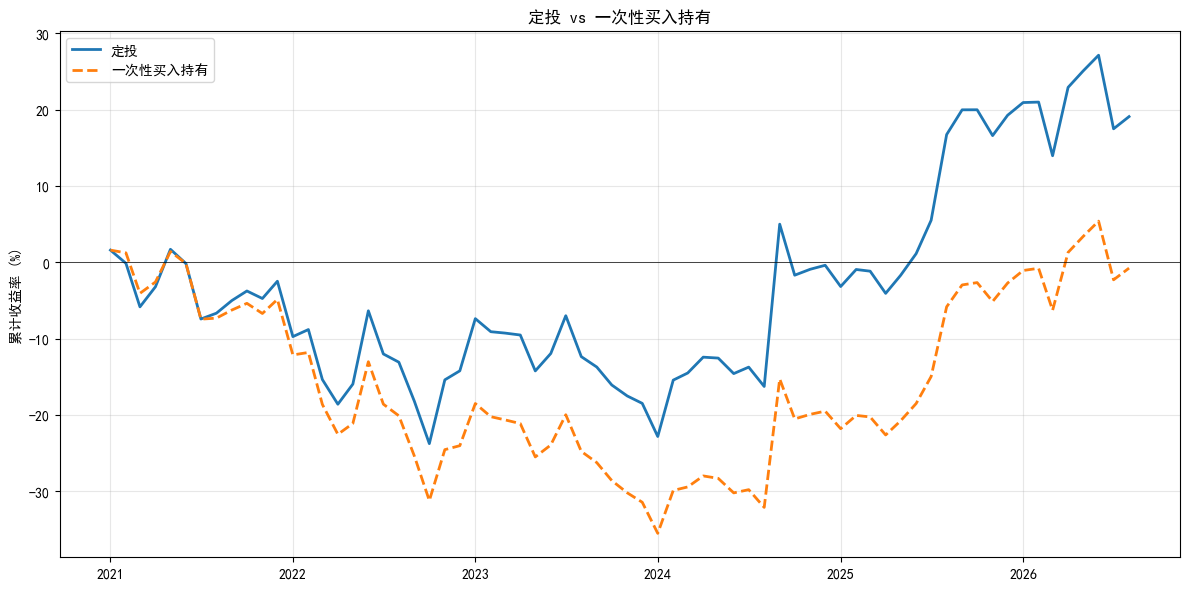

In [3]:
initial_price = df['Close'].iloc[0]
final_price = df['Close'].iloc[-1]
benchmark_return = (final_price - initial_price) / initial_price

dca_return = result_dca['return'].iloc[-1]

print(f"沪深300ETF 起点价格: {initial_price:.3f}")
print(f"沪深300ETF 终点价格: {final_price:.3f}")
print(f"\n一次性买入收益率: {benchmark_return:.2%}")
print(f"定投收益率: {dca_return:.2%}")
print(f"差异: {dca_return - benchmark_return:.2%}")

print(f"沪深300ETF 起点价格: {initial_price:.3f}")
print(f"沪深300ETF 终点价格: {final_price:.3f}")
print(f"\n一次性买入收益率: {benchmark_return:.2%}")
print(f"定投收益率: {dca_return:.2%}")
print(f"差异: {dca_return - benchmark_return:.2%}")

if dca_return > benchmark_return:
    print("\n→ 定投跑赢了一次性买入！")
    print("  在下跌市中，定投通过分批买入避开了部分高位。")
else:
    print("\n→ 定投跑输了一次性买入！")
    print("  在上涨市中，越早全部投入越好。")

print("\n但两种策略都没有 Alpha——收益完全取决于市场涨跌，这就是 Beta。")

df_monthly = df.copy()
df_monthly['month'] = df_monthly.index.to_period('M')
monthly_last = df_monthly.groupby('month').last()
bnh_monthly_return = (monthly_last['Close'].values - initial_price) / initial_price

fig, ax = plt.subplots(figsize=(12, 6))
ts = result_dca.index.to_timestamp()
ax.plot(ts, result_dca['return'] * 100, label='定投', linewidth=2)
ax.plot(ts, bnh_monthly_return * 100, label='一次性买入持有', linewidth=2, linestyle='--')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('累计收益率 (%)')
ax.set_title('定投 vs 一次性买入持有')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

均线

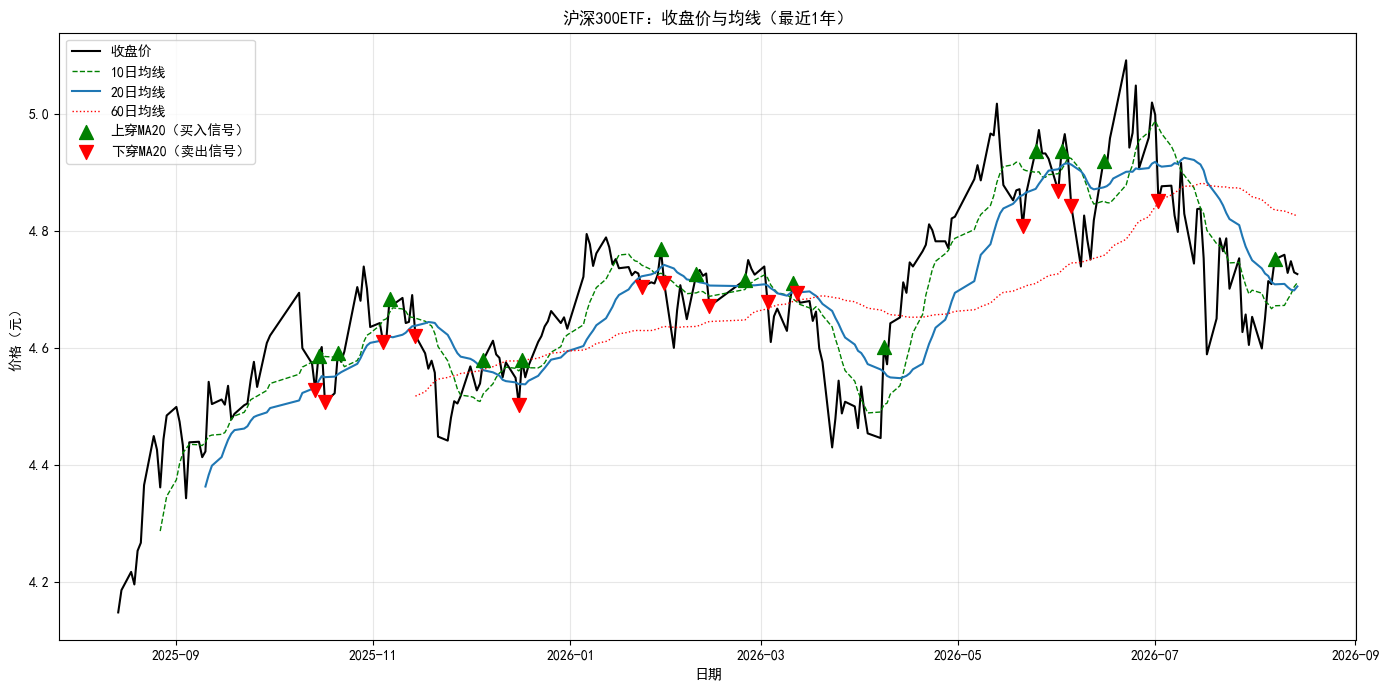


MA20 交叉统计（最近1年）：
  上穿（买入信号）：14 次
  下穿（卖出信号）：14 次


In [4]:
# 取最近一年的数据，计算三条均线
one_year_ago = df.index[-1] - pd.DateOffset(years=1)
df_recent = df.loc[one_year_ago:].copy()
ma10 = df_recent['Close'].rolling(10).mean()
ma20 = df_recent['Close'].rolling(20).mean()
ma60 = df_recent['Close'].rolling(60).mean()

# 收盘价与 ma20 的交叉点
cross_up = (df_recent['Close'].shift(1) <= ma20.shift(1)) & (df_recent['Close'] > ma20)
cross_down = (df_recent['Close'].shift(1) >= ma20.shift(1)) & (df_recent['Close'] < ma20)

# 画图
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_recent.index, df_recent['Close'], color='black', linewidth=1.5, label='收盘价')
ax.plot(df_recent.index, ma10, color='green', linewidth=1, linestyle='--', label='10日均线')
ax.plot(df_recent.index, ma20, color='#1f77b4', linewidth=1.5, linestyle='-', label='20日均线')
ax.plot(df_recent.index, ma60, color='red', linewidth=1, linestyle=':', label='60日均线')

# 标记交叉点
ax.scatter(df_recent.index[cross_up], df_recent['Close'][cross_up],
           marker='^', color='green', s=100, zorder=5, label='上穿MA20（买入信号）')
ax.scatter(df_recent.index[cross_down], df_recent['Close'][cross_down],
           marker='v', color='red', s=100, zorder=5, label='下穿MA20（卖出信号）')

ax.set_title('沪深300ETF：收盘价与均线（最近1年）')
ax.set_xlabel('日期')
ax.set_ylabel('价格（元）')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 交叉统计
print(f"\nMA20 交叉统计（最近1年）：")
print(f"  上穿（买入信号）：{cross_up.sum()} 次")
print(f"  下穿（卖出信号）：{cross_down.sum()} 次")

## 均线上下穿择时：MA10 / MA20 / MA60 与定投对比

为保证比较公平，定投和择时策略使用相同现金流：每月第一个交易日新增 1000 元。收盘价上穿均线后进入多头、下穿后清仓；信号在当日收盘后才确定，因此统一在下一交易日收盘执行，避免未来函数。现金不计利息，暂不考虑手续费和滑点。

均线上下穿择时（每月投入 1000 元）
MA 10: 最终收益率   0.04%, 买入 123 次, 卖出 122 次
MA 20: 最终收益率   4.56%, 买入 87 次, 卖出 86 次
MA 60: 最终收益率  15.03%, 买入 44 次, 卖出 44 次
定投 : 最终收益率  19.08%


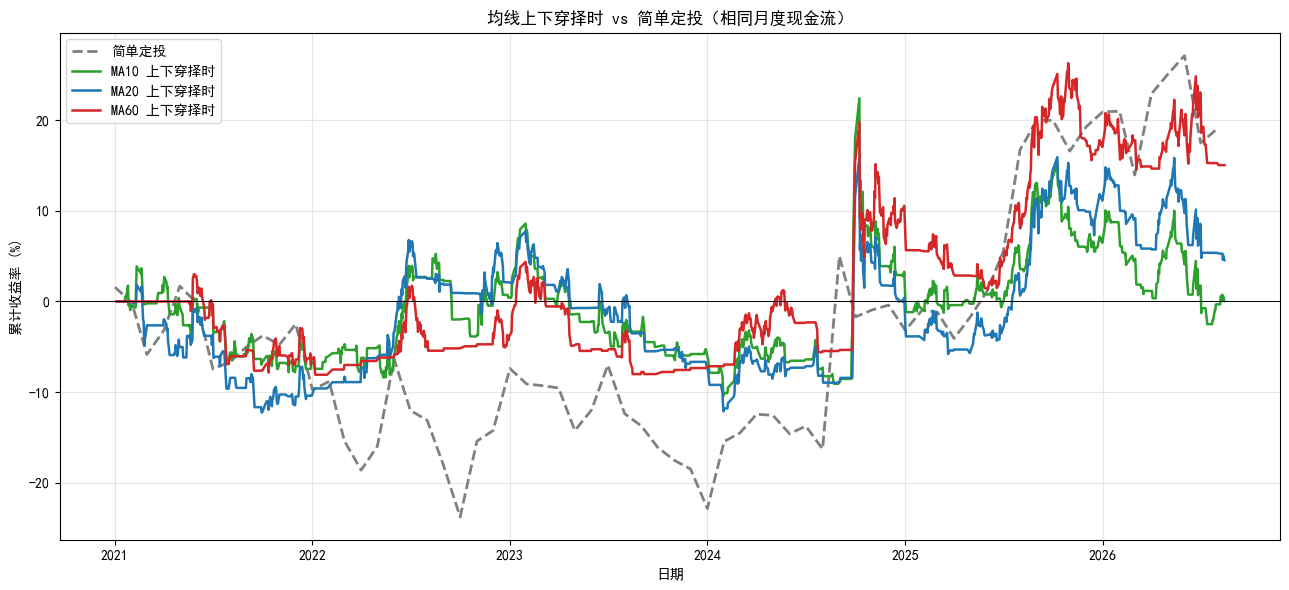

In [5]:
def build_ma_cross_state(data, ma_period):
    """计算均线、交叉信号和下一交易日执行的目标仓位。"""
    close = data['Close'].astype(float).sort_index()
    ma = close.rolling(ma_period, min_periods=ma_period).mean()
    valid_pair = ma.notna() & ma.shift(1).notna()

    cross_up = valid_pair & (close.shift(1) <= ma.shift(1)) & (close > ma)
    cross_down = valid_pair & (close.shift(1) >= ma.shift(1)) & (close < ma)

    # 交叉发生在当天收盘；目标状态从下一交易日开始生效。
    state_event = pd.Series(np.nan, index=close.index, dtype=float)
    state_event.loc[cross_up] = 1.0
    state_event.loc[cross_down] = 0.0
    signal_state = state_event.ffill().fillna(0.0)
    position = signal_state.shift(1).fillna(0.0).astype(int)

    return pd.DataFrame({
        'Close': close,
        'ma': ma,
        'cross_up': cross_up,
        'cross_down': cross_down,
        'position': position,
    })


def backtest_ma_cross(data, ma_period, monthly_amount=1000, start=None, end=None):
    """
    同额现金流的均线上下穿回测。

    每月第一个交易日注入 monthly_amount；目标仓位为 1 时投入全部现金，
    目标仓位为 0 时清仓。MA 使用传入 data 的全部既有历史计算，
    start/end 只限制评价和现金流区间，便于验证集使用训练期历史作预热。
    """
    state = build_ma_cross_state(data, ma_period)
    period = state.loc[start:end].copy()
    if period.empty:
        raise ValueError('回测区间没有数据')

    cash = 0.0
    shares = 0.0
    total_contribution = 0.0
    previous_month = None
    records = []

    for date, row in period.iterrows():
        current_month = date.to_period('M')
        if current_month != previous_month:
            cash += monthly_amount
            total_contribution += monthly_amount
            previous_month = current_month

        price = float(row['Close'])
        if int(row['position']) == 1 and cash > 0:
            shares += cash / price
            cash = 0.0
        elif int(row['position']) == 0 and shares > 0:
            cash += shares * price
            shares = 0.0

        portfolio_value = cash + shares * price
        cumulative_return = portfolio_value / total_contribution - 1
        records.append({
            'Close': price,
            'ma': row['ma'],
            'cross_up': bool(row['cross_up']),
            'cross_down': bool(row['cross_down']),
            'position': int(row['position']),
            'cash': cash,
            'shares': shares,
            'total_contribution': total_contribution,
            'portfolio_value': portfolio_value,
            'return': cumulative_return,
        })

    return pd.DataFrame(records, index=period.index)


# MA10 / MA20 / MA60 与相同月度现金流的简单定投比较
ma_periods = [10, 20, 60]
ma_cross_results = {
    ma: backtest_ma_cross(df, ma_period=ma, start=DATA_START, end=DATA_END)
    for ma in ma_periods
}

print('均线上下穿择时（每月投入 1000 元）')
print('=' * 55)
for ma, result in ma_cross_results.items():
    position_change = result['position'].diff()
    entries = int((position_change == 1).sum() + (result['position'].iloc[0] == 1))
    exits = int((position_change == -1).sum())
    print(
        f'MA{ma:>3}: 最终收益率 {result["return"].iloc[-1]:7.2%}, '
        f'买入 {entries:2d} 次, 卖出 {exits:2d} 次'
    )
print(f'定投 : 最终收益率 {result_dca["return"].iloc[-1]:7.2%}')

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(
    result_dca.index.to_timestamp(),
    result_dca['return'] * 100,
    color='gray',
    linestyle='--',
    linewidth=2,
    label='简单定投',
)
colors = {10: '#2ca02c', 20: '#1f77b4', 60: '#d62728'}
for ma, result in ma_cross_results.items():
    ax.plot(
        result.index,
        result['return'] * 100,
        linewidth=1.8,
        color=colors[ma],
        label=f'MA{ma} 上下穿择时',
    )
ax.axhline(0, color='black', linewidth=0.7)
ax.set_title('均线上下穿择时 vs 简单定投（相同月度现金流）')
ax.set_xlabel('日期')
ax.set_ylabel('累计收益率 (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## MA5–MA120 参数搜索与样本外验证

训练集固定为 2021-01-04 至 2024-01-31，验证集固定为 2024-02-01 至 2026-08-14。遍历 5 到 120 的每一个整数周期（共 116 个参数），以训练集最终累计收益率选出最优参数。验证期均线只使用当日及此前价格；训练期历史仅作为均线预热，不使用任何验证期未来数据选参。

训练集: 2021-01-04 到 2024-01-31，749 条
验证集: 2024-02-01 到 2026-08-14，611 条
扫描参数: MA5 到 MA120，共 116 个整数参数

训练集最优参数: MA47
训练集最终收益率: 0.58%
验证集 MA47 最终收益率: 11.67%
验证集简单定投最终收益率: 19.46%
验证集相对定投差异: -7.79%

结论：训练集最优参数未能在样本外跑赢定投，存在明显过拟合风险。


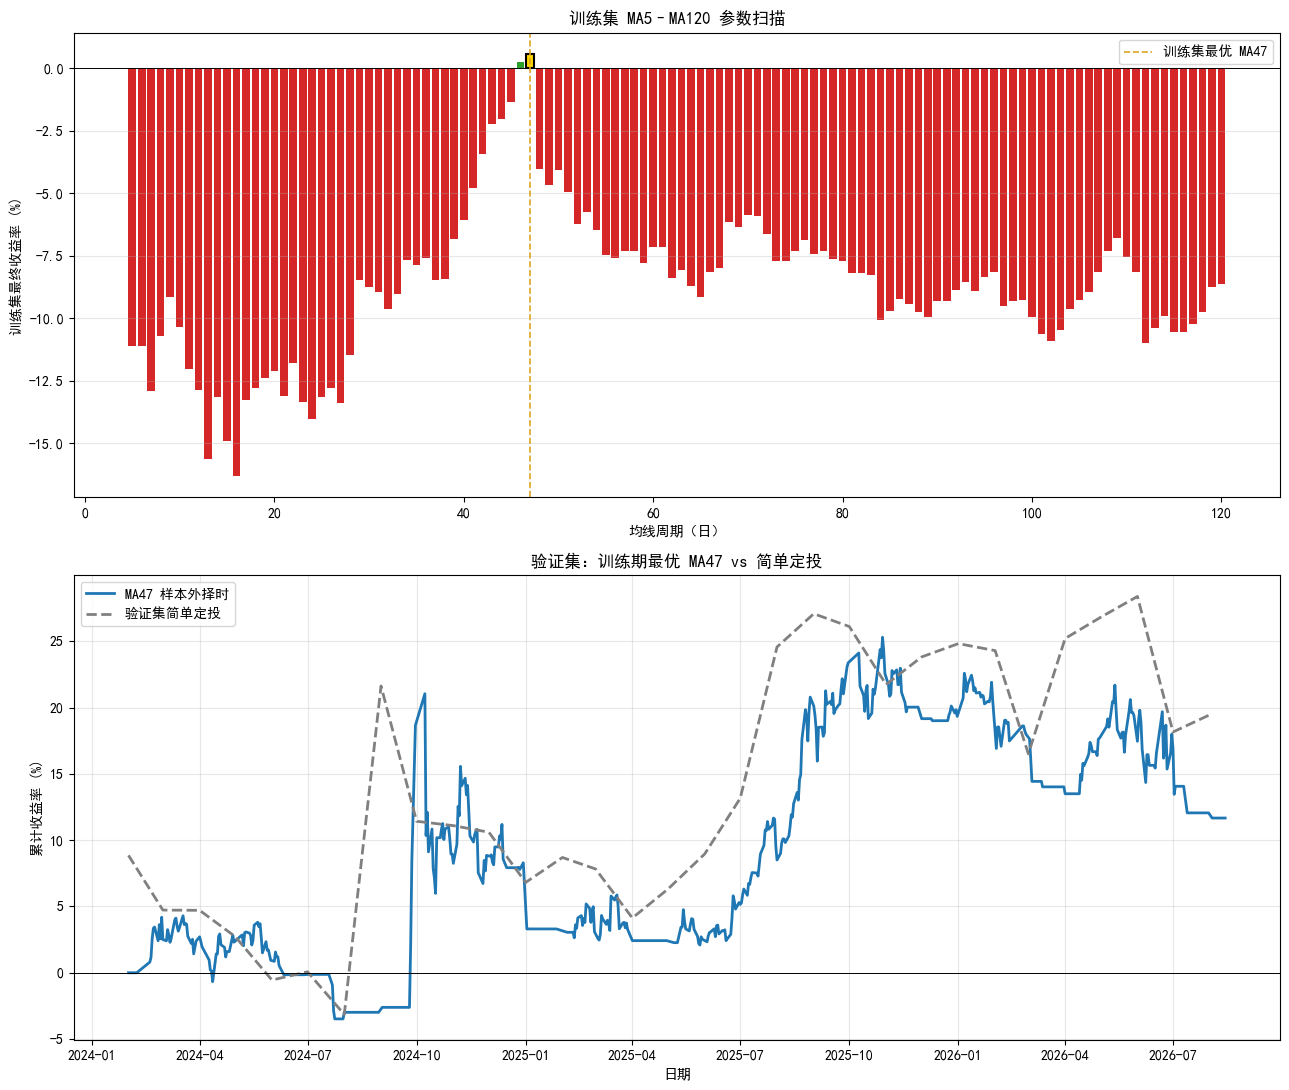

In [6]:
TRAIN_START = '2021-01-04'
TRAIN_END = '2024-01-31'
VALID_START = '2024-02-01'
VALID_END = '2026-08-14'
MA_CANDIDATES = range(5, 121)  # 5, 6, ..., 120，共 116 个参数

train_prices = df.loc[TRAIN_START:TRAIN_END]
valid_prices = df.loc[VALID_START:VALID_END]
if train_prices.empty or valid_prices.empty:
    raise ValueError('训练集或验证集为空，请检查数据日期范围')
if train_prices.index.max() >= valid_prices.index.min():
    raise ValueError('训练集和验证集发生重叠')

scan_records = []
train_results = {}
for ma in MA_CANDIDATES:
    result = backtest_ma_cross(
        df,
        ma_period=ma,
        start=TRAIN_START,
        end=TRAIN_END,
    )
    train_results[ma] = result
    position_change = result['position'].diff()
    entries = int((position_change == 1).sum() + (result['position'].iloc[0] == 1))
    scan_records.append({
        'ma': ma,
        'train_return': float(result['return'].iloc[-1]),
        'entries': entries,
    })

train_scan = pd.DataFrame(scan_records).set_index('ma')
best_ma = int(train_scan['train_return'].idxmax())
best_train_result = train_results[best_ma]
best_train_return = float(best_train_result['return'].iloc[-1])

# 最优参数固定后才查看验证集；验证期从零资金、相同月度现金流开始。
best_valid_result = backtest_ma_cross(
    df,
    ma_period=best_ma,
    start=VALID_START,
    end=VALID_END,
)
valid_dca_result = backtest_dca(valid_prices)
best_valid_return = float(best_valid_result['return'].iloc[-1])
valid_dca_return = float(valid_dca_result['return'].iloc[-1])

print(f'训练集: {train_prices.index[0].date()} 到 {train_prices.index[-1].date()}，{len(train_prices)} 条')
print(f'验证集: {valid_prices.index[0].date()} 到 {valid_prices.index[-1].date()}，{len(valid_prices)} 条')
print(f'扫描参数: MA5 到 MA120，共 {len(train_scan)} 个整数参数')
print(f'\n训练集最优参数: MA{best_ma}')
print(f'训练集最终收益率: {best_train_return:.2%}')
print(f'验证集 MA{best_ma} 最终收益率: {best_valid_return:.2%}')
print(f'验证集简单定投最终收益率: {valid_dca_return:.2%}')
print(f'验证集相对定投差异: {best_valid_return - valid_dca_return:+.2%}')

if best_valid_return > valid_dca_return:
    print('\n结论：样本外暂时跑赢定投，但一次验证不足以证明参数稳定。')
else:
    print('\n结论：训练集最优参数未能在样本外跑赢定投，存在明显过拟合风险。')

fig, axes = plt.subplots(2, 1, figsize=(13, 11))

ax1 = axes[0]
bar_colors = [
    'gold' if ma == best_ma else ('#2ca02c' if value >= 0 else '#d62728')
    for ma, value in train_scan['train_return'].items()
]
ax1.bar(
    train_scan.index,
    train_scan['train_return'] * 100,
    color=bar_colors,
    edgecolor=['black' if ma == best_ma else 'none' for ma in train_scan.index],
    linewidth=[1.5 if ma == best_ma else 0 for ma in train_scan.index],
)
ax1.axhline(0, color='black', linewidth=0.7)
ax1.axvline(best_ma, color='goldenrod', linestyle='--', linewidth=1.2, label=f'训练集最优 MA{best_ma}')
ax1.set_title('训练集 MA5–MA120 参数扫描')
ax1.set_xlabel('均线周期（日）')
ax1.set_ylabel('训练集最终收益率 (%)')
ax1.legend()
ax1.grid(True, axis='y', alpha=0.3)

ax2 = axes[1]
ax2.plot(
    best_valid_result.index,
    best_valid_result['return'] * 100,
    linewidth=2,
    label=f'MA{best_ma} 样本外择时',
)
ax2.plot(
    valid_dca_result.index.to_timestamp(),
    valid_dca_result['return'] * 100,
    color='gray',
    linestyle='--',
    linewidth=2,
    label='验证集简单定投',
)
ax2.axhline(0, color='black', linewidth=0.7)
ax2.set_title(f'验证集：训练期最优 MA{best_ma} vs 简单定投')
ax2.set_xlabel('日期')
ax2.set_ylabel('累计收益率 (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()